# Laboratorio 9

Primero vamos ver las columnas de cada csv 

## Preparar dataset

### Juntar Hechos

In [38]:
import pandas as pd
import glob
import os

# Ruta de tus archivos
ruta = os.path.join("..", "working_dir", "hechos", "Hechos_*.csv")
archivos = sorted(glob.glob(ruta))

# Mapeo de nombres distintos a uno estándar
columnas_equivalentes = {
    'Año_ocu': 'año_ocu',
    'Día_ocu': 'día_ocu',
    'Hora_ocu': 'hora_ocu',
    'Mes_ocu': 'mes_ocu',
    'Núm_corre': 'num_corre',
    'núm_corre': 'num_corre',
    'num_correlativo': 'num_corre',
    '﻿núm_corre': 'num_corre',
    '﻿num_corre': 'num_corre',
    'día_sem_ocu': 'dia_sem_ocu',
    'día_ocu': 'dia_ocu',
    'área_geo_ocu': 'area_geo_ocu',
    'zona_ciudad': 'zona_ciudad'
}

dfs = []

for archivo in archivos:
    # Leer CSV como texto
    df = pd.read_csv(archivo, encoding='utf-8', dtype=str, low_memory=False)
    
    # Estandarizar nombres de columnas
    df.columns = [c.strip().lower() for c in df.columns]
    df.rename(columns=columnas_equivalentes, inplace=True)
    
    # Añadir columna de año si no existe
    if 'año_ocu' not in df.columns:
        df['año_ocu'] = archivo.split('_')[-1].split('.')[0]
    
    # Convertir todo a str
    df = df.astype(str)
    
    dfs.append(df)

# Concatenar todos los DataFrames: esto automáticamente añade columnas nuevas que no existían en otros archivos
hechos_total = pd.concat(dfs, ignore_index=True, sort=False)

# Convertir todo a str nuevamente, por seguridad
hechos_total = hechos_total.astype(str)

# Guardar CSV final
output_file = os.path.join("..", "working_dir", "Datos_Hechos_2013_2023.csv")
hechos_total.to_csv(output_file, index=False, encoding='utf-8')

print(f"✅ Archivo CSV guardado en: {output_file}")


✅ Archivo CSV guardado en: ../working_dir/Datos_Hechos_2013_2023.csv


In [39]:


# 1️⃣ Combinar las columnas 'causa_acc' y 'tipo_eve' en 'tipo_accidente'
hechos_total['tipo_accidente'] = hechos_total[['causa_acc', 'tipo_eve']].apply(
    lambda x: ' '.join([str(i) for i in x if pd.notna(i) and str(i).lower() != 'nan']).strip(),
    axis=1
)

# 2️⃣ Conservar solo las columnas deseadas
columnas_finales = [
    'dia_ocu', 'mes_ocu', 'año_ocu', 'hora_ocu',
    'depto_ocu', 'mupio_ocu', 'tipo_veh',
    'color_veh', 'modelo_veh', 'tipo_accidente', 'marca_veh'
]

# Crear columnas vacías si faltan
for col in columnas_finales:
    if col not in hechos_total.columns:
        hechos_total[col] = ''

hechos_total = hechos_total[columnas_finales]

# 3️⃣ Guardar CSV final
output_file = os.path.join("..", "working_dir", "Datos_Hechos_2013_2023.csv")
hechos_total.to_csv(output_file, index=False, encoding='utf-8')

print(f"✅ Archivo CSV guardado en: {output_file}")


✅ Archivo CSV guardado en: ../working_dir/Datos_Hechos_2013_2023.csv


### Juntar Lesionados

In [37]:
import pandas as pd
import glob
import os
import numpy as np

ruta_lesionados = os.path.join("..", "working_dir", "lesionados", "Lesionados_*.csv")
archivos_lesionados = sorted(glob.glob(ruta_lesionados))

columnas_equivalentes_lesionados = {
    'num_hecho': 'num_corre',
    'num_correlativo': 'num_corre',
    'núm_corre': 'num_corre',
    '\ufeff\ufeffnum_corre': 'num_corre',
    '\ufeff\ufeffnúm_corre': 'num_corre',
    
    'tipo_eve': 'tipo_lesion',
    'tipo_lesion': 'tipo_lesion',
    'tipo_eve_cod': 'tipo_lesion',
    
    'sexo_per': 'sexo',
    'sexo_víc': 'sexo',
    'sexo_pil': 'sexo',
    
    'edad_per': 'edad',
    'edad_pil': 'edad',
    'edad_víc': 'edad',
    'edad_quinquenales': 'edad',
    
    'área_geo_ocu': 'area_geo_ocu',
    'areag_ocu': 'area_geo_ocu'
}

dfs_lesionados = []

for archivo in archivos_lesionados:
    df = pd.read_csv(archivo, encoding='utf-8', dtype=str, low_memory=False)
    
    # Estandarizar nombres
    df.columns = [c.strip().lower() for c in df.columns]
    df.rename(columns=columnas_equivalentes_lesionados, inplace=True)
    
    # Añadir año si no existe
    if 'año_ocu' not in df.columns:
        df['año_ocu'] = archivo.split('_')[-1].split('.')[0]
    
    # Convertir todo a str
    df = df.astype(str)
    
    # Eliminar columnas duplicadas, manteniendo la primera aparición
    df = df.loc[:, ~df.columns.duplicated()]
    
    dfs_lesionados.append(df)

# Concatenar DataFrames ya limpios
lesionados_total = pd.concat(dfs_lesionados, ignore_index=True, sort=False)

# Reemplazar strings vacíos o 'nan' por NaN
lesionados_total = lesionados_total.replace({'': np.nan, 'nan': np.nan})

# Guardar CSV final
output_file_lesionados = os.path.join("..", "working_dir", "Datos_Lesionados_2013_2023.csv")
lesionados_total.to_csv(output_file_lesionados, index=False, encoding='utf-8')

print(f"✅ Archivo CSV de lesionados guardado en: {output_file_lesionados}")


✅ Archivo CSV de lesionados guardado en: ../working_dir/Datos_Lesionados_2013_2023.csv


In [41]:


# Leer el CSV ya existente
input_file = os.path.join("..", "working_dir", "Datos_Lesionados_2013_2023.csv")
lesionados_total = pd.read_csv(input_file, dtype=str, encoding='utf-8')

# Convertir todo a str
lesionados_total = lesionados_total.astype(str)

# Combinar columnas equivalentes: día_ocu
if 'día_ocu' in lesionados_total.columns and 'dia_ocu' in lesionados_total.columns:
    lesionados_total['dia_ocu'] = lesionados_total[['día_ocu', 'dia_ocu']].apply(
        lambda x: next((v for v in x if v and v.lower() != 'nan'), np.nan), axis=1
    )
    lesionados_total.drop(columns=['día_ocu'], inplace=True)
elif 'día_ocu' in lesionados_total.columns:
    lesionados_total.rename(columns={'día_ocu': 'dia_ocu'}, inplace=True)

# Combinar columnas equivalentes: fall_les y fallecidos_lesionados
if 'fall_les' in lesionados_total.columns and 'fallecidos_lesionados' in lesionados_total.columns:
    lesionados_total['fallecidos_lesionados'] = lesionados_total[['fall_les', 'fallecidos_lesionados']].apply(
        lambda x: next((v for v in x if v and v.lower() != 'nan'), np.nan), axis=1
    )
    lesionados_total.drop(columns=['fall_les'], inplace=True)
elif 'fall_les' in lesionados_total.columns:
    lesionados_total.rename(columns={'fall_les': 'fallecidos_lesionados'}, inplace=True)

# Columnas a conservar en el orden deseado
columnas_finales = [
    'num_corre', 'dia_ocu', 'mes_ocu', 'hora_ocu', 'depto_ocu', 'mupio_ocu',
    'año_ocu', 'tipo_veh', 'marca_veh', 'color_veh', 'modelo_veh', 'edad',
    'fallecidos_lesionados'  # si quieres conservar esta columna combinada
]

# Crear columnas faltantes si no existen
for col in columnas_finales:
    if col not in lesionados_total.columns:
        lesionados_total[col] = np.nan

# Reordenar columnas
lesionados_total = lesionados_total[columnas_finales]

# Guardar CSV final limpio
output_file = os.path.join("..", "working_dir", "Datos_Lesionados_2013_2023.csv")
lesionados_total.to_csv(output_file, index=False, encoding='utf-8')

print(f"✅ CSV limpio de lesionados guardado en: {output_file}")


✅ CSV limpio de lesionados guardado en: ../working_dir/Datos_Lesionados_2013_2023.csv


### Juntar todos en un dataset

In [42]:
import pandas as pd

# Rutas de los archivos
archivo_hechos = "../working_dir/Datos_Hechos_2013_2023.csv"
archivo_lesionados = "../working_dir/Datos_Lesionados_2013_2023.csv"

# Leer solo los encabezados para ver columnas
df_hechos = pd.read_csv(archivo_hechos, nrows=0, dtype=str, encoding='utf-8')
df_lesionados = pd.read_csv(archivo_lesionados, nrows=0, dtype=str, encoding='utf-8')

print("Columnas de Datos_Hechos_2013_2023:")
print(df_hechos.columns.tolist())
print("-" * 50)

print("Columnas de Datos_Lesionados_2013_2023:")
print(df_lesionados.columns.tolist())
print("-" * 50)


Columnas de Datos_Hechos_2013_2023:
['dia_ocu', 'mes_ocu', 'año_ocu', 'hora_ocu', 'depto_ocu', 'mupio_ocu', 'tipo_veh', 'color_veh', 'modelo_veh', 'tipo_accidente', 'marca_veh']
--------------------------------------------------
Columnas de Datos_Lesionados_2013_2023:
['num_corre', 'dia_ocu', 'mes_ocu', 'hora_ocu', 'depto_ocu', 'mupio_ocu', 'año_ocu', 'tipo_veh', 'marca_veh', 'color_veh', 'modelo_veh', 'edad', 'fallecidos_lesionados']
--------------------------------------------------


In [43]:
import pandas as pd

# Ruta del archivo de lesionados
archivo_lesionados = "../working_dir/Datos_Lesionados_2013_2023.csv"

# Leer solo la columna relevante como texto
df_lesionados = pd.read_csv(archivo_lesionados, usecols=['fallecidos_lesionados'], dtype=str, encoding='utf-8')

# Ver valores únicos
valores_unicos = df_lesionados['fallecidos_lesionados'].unique()
print("Valores únicos en 'fallecidos_lesionados':")
print(valores_unicos)

# Opcional: contar cuántas veces aparece cada valor
conteo_valores = df_lesionados['fallecidos_lesionados'].value_counts(dropna=False)
print("\nConteo de cada valor:")
print(conteo_valores)


Valores únicos en 'fallecidos_lesionados':
['2.0' '1.0' '2' '1' '12' '3' '4' '5' '6' '7' '8' '9' '10' '11'
 'Lesionado' 'Fallecido' 'Ignorado']

Conteo de cada valor:
fallecidos_lesionados
2            49993
Lesionado    17466
2.0          15940
1            11038
Fallecido     4451
1.0           3664
3             1468
4             1194
5              944
6              728
11             655
7              489
8              391
12             374
9              355
10             264
Ignorado         3
Name: count, dtype: int64


In [48]:
import pandas as pd

# Rutas
archivo_hechos = "../working_dir/Datos_Hechos_2013_2023.csv"
archivo_lesionados = "../working_dir/Datos_Lesionados_2013_2023.csv"
archivo_salida = "../working_dir/Datos_Accidentes_2013_2023.csv"

# Leer CSVs
df_hechos = pd.read_csv(archivo_hechos, dtype=str, encoding='utf-8')
df_lesionados = pd.read_csv(archivo_lesionados, dtype=str, encoding='utf-8')

# Columnas clave para identificar un accidente
key_cols = ['dia_ocu', 'mes_ocu', 'hora_ocu', 'depto_ocu', 'mupio_ocu', 'año_ocu']

# Contar número de vehículos por accidente
vehiculos_por_accidente = df_hechos.groupby(key_cols)['tipo_veh'].nunique().reset_index()
vehiculos_por_accidente.rename(columns={'tipo_veh': 'numero_vehiculos_involucrados'}, inplace=True)

# Contar cuántas personas (lesionados o fallecidos) hay por accidente
fallecidos_lesionados = df_lesionados.groupby(key_cols).size().reset_index(name='fallecidos_lesionados')

# Unir todo en un solo DataFrame
df_final = pd.merge(vehiculos_por_accidente, fallecidos_lesionados, on=key_cols, how='outer')

# Rellenar valores por defecto
df_final['numero_vehiculos_involucrados'] = df_final['numero_vehiculos_involucrados'].fillna(1).astype(int)
df_final['fallecidos_lesionados'] = df_final['fallecidos_lesionados'].fillna(0).astype(int)

# Ordenar por fecha y hora
df_final = df_final.sort_values(by=['año_ocu', 'mes_ocu', 'dia_ocu', 'hora_ocu']).reset_index(drop=True)

# Guardar en CSV
df_final.to_csv(archivo_salida, index=False, encoding='utf-8')

print(f"Archivo guardado en: {archivo_salida}")


Archivo guardado en: ../working_dir/Datos_Accidentes_2013_2023.csv


Archivo guardado en: ../working_dir/Datos_Accidentes_2013_2023.csv


In [6]:
from unidecode import unidecode

def normalizar_valores_map(original_map):
    
    return {k: unidecode(v).lower().strip() for k, v in original_map.items()}


muni_map = {
    101: 'Guatemala',
    102: 'Santa Catarina Pinula',
    103: 'San José Pinula',
    104: 'San José del Golfo',
    105: 'Palencia',
    106: 'Chinautla',
    107: 'San Pedro Ayampuc',
    108: 'Mixco',
    109: 'San Pedro Sacatepéquez',
    110: 'San Juan Sacatepéquez',
    111: 'San Raymundo',
    112: 'Chuarrancho',
    113: 'Fraijanes',
    114: 'Amatitlán',
    115: 'Villa Nueva',
    116: 'Villa Canales',
    117: 'Petapa',
    201: 'Guastatoya',
    202: 'Morazán',
    203: 'San Agustín Acasaguastlán',
    204: 'San Cristóbal Acasaguastlán',
    205: 'El Jícaro',
    206: 'Sansare',
    207: 'Sanarate',
    208: 'San Antonio la Paz',
    301: 'Antigua Guatemala',
    302: 'Jocotenango',
    303: 'Pastores',
    304: 'Sumpango',
    305: 'Santo Domingo Xenacoj',
    306: 'Santiago Sacatepéquez',
    307: 'San Bartolomé Milpas Altas',
    308: 'San Lucas Sacatepéquez',
    309: 'Santa Lucía Milpas Altas',
    310: 'Magdalena Milpas Altas',
    311: 'Santa María de Jesús',
    312: 'Ciudad Vieja',
    313: 'San Miguel Dueñas',
    314: 'San Juan Alotenango',
    315: 'San Antonio Aguas Calientes',
    316: 'Santa Catarina Barahona',
    401: 'Chimaltenango',
    402: 'San José Poaquíl',
    403: 'San Martín Jilotepeque',
    404: 'Comalapa',
    405: 'Santa Apolonia',
    406: 'Tecpán Guatemala',
    407: 'Patzún',
    408: 'San Miguel Pochuta',
    409: 'Patzicía',
    410: 'Santa Cruz Balanyá',
    411: 'Acatenango',
    412: 'Yepocapa',
    413: 'San Andrés Itzapa',
    414: 'Parramos',
    415: 'Zaragoza',
    416: 'El Tejar',
    501: 'Escuintla',
    502: 'Santa Lucía Cotzumalguapa',
    503: 'La Democracia',
    504: 'Siquinalá',
    505: 'Masagua',
    506: 'Tiquisate',
    507: 'La Gomera',
    508: 'Guanagazapa',
    509: 'San José',
    510: 'Iztapa',
    511: 'Palín',
    512: 'San Vicente Pacaya',
    513: 'Nueva Concepción',
    514: 'Sipacate',
    601: 'Cuilapa',
    602: 'Barberena',
    603: 'Santa Rosa de Lima',
    604: 'Casillas',
    605: 'San Rafael las Flores',
    606: 'Oratorio',
    607: 'San Juan Tecuaco',
    608: 'Chiquimulilla',
    609: 'Taxisco',
    610: 'Santa María Ixhuatán',
    611: 'Guazacapán',
    612: 'Santa Cruz el Naranjo',
    613: 'Pueblo Nuevo Viñas',
    614: 'Nueva Santa Rosa',
    701: 'Sololá',
    702: 'San José Chacayá',
    703: 'Santa María Visitación',
    704: 'Santa Lucía Utatlán',
    705: 'Nahualá',
    706: 'Santa Catarina Ixtahuacán',
    707: 'Santa Clara la Laguna',
    708: 'Concepción',
    709: 'San Andrés Semetabaj',
    710: 'Panajachel',
    711: 'Santa Catarina Palopó',
    712: 'San Antonio Palopó',
    713: 'San Lucas Tolimán',
    714: 'Santa Cruz la Laguna',
    715: 'San Pablo la Laguna',
    716: 'San Marcos la Laguna',
    717: 'San Juan la Laguna',
    718: 'San Pedro la Laguna',
    719: 'Santiago Atitlán',
    801: 'Totonicapán',
    802: 'San Cristóbal Totonicapán',
    803: 'San Francisco el Alto',
    804: 'San Andrés Xecul',
    805: 'Momostenango',
    806: 'Santa María Chiquimula',
    807: 'Santa Lucía la Reforma',
    808: 'San Bartolo Aguas Calientes',
    901: 'Quetzaltenango',
    902: 'Salcajá',
    903: 'Olintepeque',
    904: 'San Carlos Sija',
    905: 'Sibilia',
    906: 'Cabricán',
    907: 'Cajolá',
    908: 'San Miguel Siguilá',
    909: 'San Juan Ostuncalco',
    910: 'San Mateo',
    911: 'Concepción Chiquirichapa',
    912: 'San Martín Sacatepéquez',
    913: 'Almolonga',
    914: 'Cantel',
    915: 'Huitán',
    916: 'Zunil',
    917: 'Colomba',
    918: 'San Francisco la Unión',
    919: 'El Palmar',
    920: 'Coatepeque',
    921: 'Génova',
    922: 'Flores Costa Cuca',
    923: 'La Esperanza',
    924: 'Palestina de los Altos',
    1001: 'Mazatenango',
    1002: 'Cuyotenango',
    1003: 'San Francisco Zapotitlán',
    1004: 'San Bernardino',
    1005: 'San José el Ídolo',
    1006: 'Santo Domingo Suchitepéquez',
    1007: 'San Lorenzo',
    1008: 'Samayac',
    1009: 'San Pablo Jocopilas',
    1010: 'San Antonio Suchitepéquez',
    1011: 'San Miguel Panán',
    1012: 'San Gabriel',
    1013: 'Chicacao',
    1014: 'Patulul',
    1015: 'Santa Bárbara',
    1016: 'San Juan Bautista',
    1017: 'Santo Tomas la Unión',
    1018: 'Zunilito',
    1019: 'Pueblo Nuevo',
    1020: 'Río Bravo',
    1021: 'San José La Máquina',
    1101: 'Retalhuleu',
    1102: 'San Sebastián',
    1103: 'Santa Cruz Muluá',
    1104: 'San Martín Zapotitlán',
    1105: 'San Felipe Retalhuleu',
    1106: 'San Andrés Villa Seca',
    1107: 'Champerico',
    1108: 'Nuevo San Carlos',
    1109: 'El Asintal',
    1201: 'San Marcos',
    1202: 'San Pedro Sacatepéquez',
    1203: 'San Antonio Sacatepéquez',
    1204: 'Comitancillo',
    1205: 'San Miguel Ixtahuacán',
    1206: 'Concepción Tutuapa',
    1207: 'Tacaná',
    1208: 'Sibinal',
    1209: 'Tajumulco',
    1210: 'Tejutla',
    1211: 'San Rafael Pie de la Cuesta',
    1212: 'Nuevo Progreso',
    1213: 'El Tumbador',
    1214: 'El Rodeo',
    1215: 'Malacatán',
    1216: 'Catarina',
    1217: 'Ayutla',
    1218: 'Ocós',
    1219: 'San Pablo',
    1220: 'El Quetzal',
    1221: 'La Reforma',
    1222: 'Pajapita',
    1223: 'Ixchiguán',
    1224: 'San José Ojetenam',
    1225: 'San Cristóbal Cucho',
    1226: 'Sipacapa',
    1227: 'Esquipulas Palo Gordo',
    1228: 'Río Blanco',
    1229: 'San Lorenzo',
    1230: 'La Blanca',
    1301: 'Huehuetenango',
    1302: 'Chiantla',
    1303: 'Malacatancito',
    1304: 'Cuilco',
    1305: 'Nentón',
    1306: 'San Pedro Necta',
    1307: 'Jacaltenango',
    1308: 'San Pedro Soloma',
    1309: 'San Ildefonso Ixtahuacán',
    1310: 'Santa Bárbara',
    1311: 'La Libertad',
    1312: 'La Democracia',
    1313: 'San Miguel Acatán',
    1314: 'San Rafael La Independencia',
    1315: 'Todos Santos Cuchumatán',
    1316: 'San Juan Atitán',
    1317: 'Santa Eulalia',
    1318: 'San Mateo Ixtatán',
    1319: 'Colotenango',
    1320: 'San Sebastián Huehuetenango',
    1321: 'Tectitán',
    1322: 'Concepción Huista',
    1323: 'San Juan Ixcoy',
    1324: 'San Antonio Huista',
    1325: 'San Sebastián Coatán',
    1326: 'Barrillas',
    1327: 'Aguacatán',
    1328: 'San Rafael Petzal',
    1329: 'San Gaspar Ixchil',
    1330: 'Santiago Chimaltenango',
    1331: 'Santa Ana Huista',
    1332: 'Unión Cantinil',
    1333: 'Petatán',
    1401: 'Santa Cruz del Quiché',
    1402: 'Chiché',
    1403: 'Chinique',
    1404: 'Zacualpa',
    1405: 'Chajul',
    1406: 'Chichicastenango',
    1407: 'Patzité',
    1408: 'San Antonio Ilotenango',
    1409: 'San Pedro Jocopilas',
    1410: 'Cunén',
    1411: 'San Juan Cotzal',
    1412: 'Joyabaj',
    1413: 'Santa María Nebaj',
    1414: 'San Andrés Sajcabajá',
    1415: 'San Miguel Uspantán',
    1416: 'Sacapulas',
    1417: 'San Bartolomé Jocotenango',
    1418: 'Canillá',
    1419: 'Chicamán',
    1420: 'Ixcán',
    1421: 'Pachalum',
    1501: 'Salamá',
    1502: 'San Miguel Chicaj',
    1503: 'Rabinal',
    1504: 'Cubulco',
    1505: 'Granados',
    1506: 'El Chol',
    1507: 'San Jerónimo',
    1508: 'Purulhá',
    1601: 'Cobán',
    1602: 'Santa Cruz Verapaz',
    1603: 'San Cristóbal Verapaz',
    1604: 'Tactic',
    1605: 'Tamahú',
    1606: 'Tucurú',
    1607: 'Panzós',
    1608: 'Senahú',
    1609: 'San Pedro Carchá',
    1610: 'San Juan Chamelco',
    1611: 'Lanquín',
    1612: 'Cahabón',
    1613: 'Chisec',
    1614: 'Chahal',
    1615: 'Fray Bartolomé de las Casas',
    1616: 'Santa Catarina La Tinta',
    1617: 'Raxruhá',
    1701: 'Flores',
    1702: 'San José',
    1703: 'San Benito',
    1704: 'San Andrés',
    1705: 'La Libertad',
    1706: 'San Francisco',
    1707: 'Santa Ana',
    1708: 'Dolores',
    1709: 'San Luis',
    1710: 'Sayaxché',
    1711: 'Melchor de Mencos',
    1712: 'Poptún',
    1713: 'Las Cruces',
    1714: 'El Chal',
    1801: 'Puerto Barrios',
    1802: 'Livingston',
    1803: 'El Estor',
    1804: 'Morales',
    1805: 'Los Amates',
    1901: 'Zacapa',
    1902: 'Estanzuela',
    1903: 'Río Hondo',
    1904: 'Gualán',
    1905: 'Teculután',
    1906: 'Usumatlán',
    1907: 'Cabañas',
    1908: 'San Diego',
    1909: 'La Unión',
    1910: 'Huité',
    1911: 'San Jorge',
    2001: 'Chiquimula',
    2002: 'San José la Arada',
    2003: 'San Juan Ermita',
    2004: 'Jocotán',
    2005: 'Camotán',
    2006: 'Olopa',
    2007: 'Esquipulas',
    2008: 'Concepción las Minas',
    2009: 'Quezaltepeque',
    2010: 'San Jacinto',
    2011: 'Ipala',
    2101: 'Jalapa',
    2102: 'San Pedro Pinula',
    2103: 'San Luis Jilotepeque',
    2104: 'San Manuel Chaparrón',
    2105: 'San Carlos Alzatate',
    2106: 'Monjas',
    2107: 'Mataquescuintla',
    2201: 'Jutiapa',
    2202: 'El Progreso',
    2203: 'Santa Catarina Mita',
    2204: 'Agua Blanca',
    2205: 'Asunción Mita',
    2206: 'Yupiltepeque',
    2207: 'Atescatempa',
    2208: 'Jerez',
    2209: 'El Adelanto',
    2210: 'Zapotitlán',
    2211: 'Comapa',
    2212: 'Jalpatagua',
    2213: 'Conguaco',
    2214: 'Moyuta',
    2215: 'Pasaco',
    2216: 'San José Acatempa',
    2217: 'Quesada'
}

muni_map = normalizar_valores_map(muni_map)


In [7]:
import pandas as pd
from unidecode import unidecode

# --- Función para limpiar texto ---
def limpiar_texto(texto):
    if pd.isna(texto):
        return texto
    return unidecode(texto).strip().lower()  # quita tildes y espacios, pasa a minúsculas

# --- Cargar dataset ---
archivo_accidentes = "../working_dir/Datos_Accidentes_2013_2023.csv"
df = pd.read_csv(archivo_accidentes, dtype=str, encoding='utf-8')

# --- Limpiar columnas de texto ---
df['mes_ocu'] = df['mes_ocu'].apply(limpiar_texto)
df['depto_ocu'] = df['depto_ocu'].apply(limpiar_texto)
df['mupio_ocu'] = df['mupio_ocu'].apply(limpiar_texto)

# --- Mapeo de meses a números ---
meses_map = {
    'enero':1, 'febrero':2, 'marzo':3, 'abril':4, 'mayo':5, 'junio':6,
    'julio':7, 'agosto':8, 'septiembre':9, 'octubre':10, 'noviembre':11, 'diciembre':12
}

# Reemplazar nombres de meses por números
df['mes_ocu'] = df['mes_ocu'].replace(meses_map)

# Para valores que eran ya números (como '1', '2.0'), limpiamos y convertimos
df['mes_ocu'] = df['mes_ocu'].str.replace('.0','', regex=False)
df['mes_ocu'] = pd.to_numeric(df['mes_ocu'], errors='coerce')
df['mes_ocu'] = df['mes_ocu'].astype('Int64')  # entero nullable

# --- Mapeo de departamentos a números ---
depto_map = {
    'guatemala':1, 'el progreso':2, 'sacatepequez':3, 'chimaltenango':4, 'escuintla':5,
    'santa rosa':6, 'solola':7, 'totonicapan':8, 'quetzaltenango':9, 'suchitequez':10,
    'retalhuleu':11, 'san marcos':12, 'huehuetenango':13, 'quiche':14, 'baja verapaz':15,
    'alta verapaz':16, 'peten':17, 'izabal':18, 'zacapa':19, 'chiquimula':20, 'jalapa':21, 'jutiapa':22
}

df['depto_ocu'] = df['depto_ocu'].replace(depto_map)
df['depto_ocu'] = pd.to_numeric(df['depto_ocu'], errors='coerce').astype('Int64')



# Invertir el muni_map para reemplazar nombres por números
muni_map_invertido = {unidecode(v).strip().lower(): k for k,v in muni_map.items()}
df['mupio_ocu'] = df['mupio_ocu'].replace(muni_map_invertido)
df['mupio_ocu'] = pd.to_numeric(df['mupio_ocu'], errors='coerce').astype('Int64')

# --- Guardar dataset limpio ---
archivo_salida = "../working_dir/Datos_Accidentes_2013_2023_Limpio.csv"
df.to_csv(archivo_salida, index=False, encoding='utf-8')

print(f"Archivo limpio guardado en: {archivo_salida}")


Archivo limpio guardado en: ../working_dir/Datos_Accidentes_2013_2023_Limpio.csv


## Analisis de Correlaciones

In [20]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, PCA
from pyspark.ml.stat import Correlation
from pyspark.sql.types import DoubleType
from pyspark.ml.clustering import KMeans

# --- Iniciar SparkSession ---
spark = SparkSession.builder \
    .appName("Analisis_Correlaciones_Accidentes") \
    .getOrCreate()

# --- Cargar CSV limpio ---
archivo_limpio = "../working_dir/Datos_Accidentes_2013_2023_Limpio.csv"
df = spark.read.csv(archivo_limpio, header=True, inferSchema=True)

# --- Identificar columnas numéricas (todas excepto depto, mes y municipio) ---
excluir_cols = ['mes_ocu', 'depto_ocu', 'mupio_ocu']
num_cols = [col for col in df.columns if col not in excluir_cols]

# --- Convertir columnas numéricas a DoubleType ---
for c in num_cols:
    df = df.withColumn(c, df[c].cast(DoubleType()))

# --- Reemplazar nulls por 0 (o usar dropna si prefieres eliminar filas) ---
for c in num_cols:
    df = df.fillna({c: 0})

# --- VectorAssembler para columnas numéricas ---
assembler = VectorAssembler(inputCols=num_cols, outputCol="features")
df_vector = assembler.transform(df)

# --- Calcular correlación de Pearson ---
corr_matrix = Correlation.corr(df_vector, "features", "pearson").collect()[0][0]

# --- Mostrar matriz de correlación ---
print("Matriz de correlación (Pearson) entre variables numéricas:")
print(corr_matrix)

# --- Convertir a DataFrame de Pandas para mejor visualización ---
import pandas as pd
import numpy as np

corr_np = np.array(corr_matrix.toArray())
df_corr = pd.DataFrame(corr_np, index=num_cols, columns=num_cols)
print("\nCorrelaciones detalladas:")
print(df_corr)

# --- Interpretación rápida ---
if 'fallecidos_lesionados' in num_cols:
    print("\nVariables con mayor correlación con la severidad del accidente (fallecidos_lesionados):")
    correl_severidad = df_corr['fallecidos_lesionados'].sort_values(ascending=False)
    print(correl_severidad)
else:
    print("\nNo se encontró la columna 'fallecidos_lesionados' para correlacionar con severidad.")


Matriz de correlación (Pearson) entre variables numéricas:
DenseMatrix([[ 1.00000000e+00,  5.41167938e-03, -8.69762522e-04,
              -4.10482835e-03,  5.03233247e-03],
             [ 5.41167938e-03,  1.00000000e+00, -2.01068645e-02,
               4.11230134e-03, -7.72366212e-03],
             [-8.69762522e-04, -2.01068645e-02,  1.00000000e+00,
              -1.09477417e-02, -8.54262780e-02],
             [-4.10482835e-03,  4.11230134e-03, -1.09477417e-02,
               1.00000000e+00,  4.34455721e-02],
             [ 5.03233247e-03, -7.72366212e-03, -8.54262780e-02,
               4.34455721e-02,  1.00000000e+00]])

Correlaciones detalladas:
                                dia_ocu  hora_ocu   año_ocu  \
dia_ocu                        1.000000  0.005412 -0.000870   
hora_ocu                       0.005412  1.000000 -0.020107   
año_ocu                       -0.000870 -0.020107  1.000000   
numero_vehiculos_involucrados -0.004105  0.004112 -0.010948   
fallecidos_lesionados       

In [ ]:
La variable con más relación lineal con la severidad es numero_vehiculos_involucrados, aunque la correlación es débil (0.043).
Las demás variables (dia_ocu, hora_ocu, año_ocu) prácticamente no tienen relación con la severidad.
Esto indica que, si se quiere construir un modelo predictivo para la severidad, el número de vehículos involucrados podría ser un predictor útil, mientras que día, hora o año tendrían muy poca influencia por sí solos.    

## PCA

In [17]:
from pyspark.ml.feature import StandardScaler

# Escalar features
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withMean=True, withStd=True)
scaler_model = scaler.fit(df_vector)
df_scaled = scaler_model.transform(df_vector)

# PCA sobre features escaladas
from pyspark.ml.feature import PCA
pca = PCA(k=2, inputCol="scaled_features", outputCol="pca_features")
model_pca = pca.fit(df_scaled)
df_pca = model_pca.transform(df_scaled)

# Mostrar primeros registros
df_pca.select("pca_features").show(5, truncate=False)


+-----------------------------------------+
|pca_features                             |
+-----------------------------------------+
|[-0.7958600368626412,-2.012702566657753] |
|[-0.7958600368626412,-2.012702566657753] |
|[-0.7958600368626412,-2.012702566657753] |
|[-1.1846943907964211,-2.0824232587917226]|
|[-0.7958600368626412,-2.012702566657753] |
+-----------------------------------------+
only showing top 5 rows



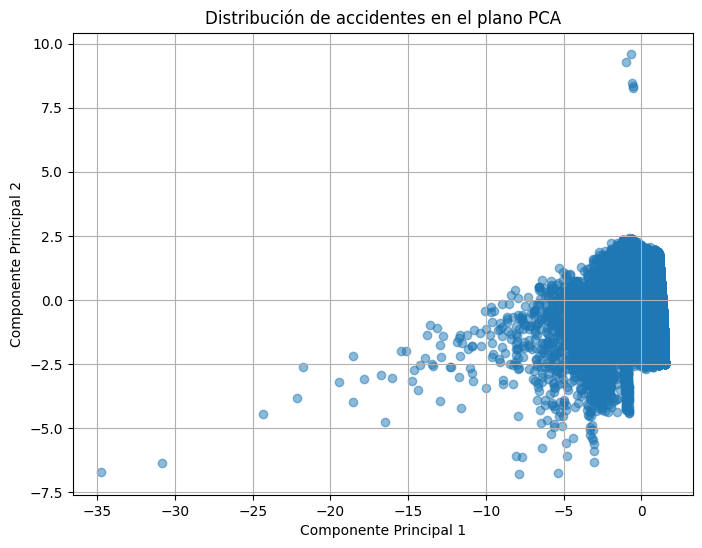

In [18]:
# Convertir a Pandas
df_plot = df_pca.select("pca_features").toPandas()

# Separar componentes
df_plot["PC1"] = df_plot["pca_features"].apply(lambda x: x[0])
df_plot["PC2"] = df_plot["pca_features"].apply(lambda x: x[1])

# Graficar
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df_plot["PC1"], df_plot["PC2"], alpha=0.5)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Distribución de accidentes en el plano PCA")
plt.grid(True)
plt.show()


### Análisis del PCA (gráfico)

El gráfico muestra la proyección de los accidentes en 2 componentes principales:
Patrones visuales identificables:

Cluster denso principal (centro-derecha del gráfico):

La mayoría de accidentes se agrupan entre PC1 = -5 a 2, PC2 = -5 a 2
Representa accidentes "típicos" o comunes


Outliers notables:
Extremo superior derecho (PC1 ≈ 0, PC2 ≈ 8-10): 2-3 accidentes muy atípicos
Extremo izquierdo (PC1 ≈ -35, PC2 ≈ -7): 1 accidente excepcional
Izquierda media (PC1 ≈ -30 a -20): Algunos casos raros


Dispersión gradual:
Hay una "cola" de puntos que se dispersan hacia la izquierda y arriba
Sugiere variabilidad en ciertos tipos de accidentes

## Segmentacion

In [22]:
k = 4 
kmeans = KMeans(featuresCol="scaled_features", predictionCol="cluster", k=k, seed=42)
model = kmeans.fit(df_scaled)
df_clusters = model.transform(df_scaled)

# --- Mostrar conteo de accidentes por clúster ---
df_clusters.groupBy("cluster").count().show()

from pyspark.sql.functions import col, mean
from pyspark.sql.types import DoubleType

for col_name in num_cols:
    df_clusters = df_clusters.withColumn(col_name, col(col_name).cast(DoubleType()))


df_clusters.groupBy("cluster").agg(*[mean(c).alias(c+"_mean") for c in num_cols]).show()


+-------+-----+
|cluster|count|
+-------+-----+
|      1| 2024|
|      3|  812|
|      2|45067|
|      0|40747|
+-------+-----+

+-------+------------------+------------------+------------------+----------------------------------+--------------------------+
|cluster|      dia_ocu_mean|     hora_ocu_mean|      año_ocu_mean|numero_vehiculos_involucrados_mean|fallecidos_lesionados_mean|
+-------+------------------+------------------+------------------+----------------------------------+--------------------------+
|      1|15.392292490118576|13.820652173913043| 2018.669466403162|                  2.04397233201581|         1.558794466403162|
|      3| 16.06896551724138|  12.8435960591133|2017.6724137931035|                1.0098522167487685|         13.72783251231527|
|      2|11.337919098231522|16.880089644307365|2017.6976723544944|                               1.0|         1.054984800408281|
|      0| 20.31997447664859|10.021523056912166|2020.3207352688542|                               